In [28]:
!git clone https://github.com/denisevaldivia/Disney_GAN.git
import os
os.chdir('Disney_GAN')

Cloning into 'Disney_GAN'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 166 (delta 4), reused 3 (delta 0), pack-reused 154 (from 1)
Receiving objects: 100% (166/166), 233.83 MiB | 32.47 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (39/39), done.


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Install dependencies for metrics
!pip install scikit-image pytorch-fid

import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

sys.path.append('/content/Disney_GAN')
from src.models.CUT_Generator import define_G_inference

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


In [31]:
import zipfile

# Paths
weights_path = "/content/drive/MyDrive/Diego/Disney_GAN/CUT_checkpoints/disney_FastCUT/latest_net_G.pth"
dataset_zip = "/content/drive/MyDrive/Diego/Disney_GAN/dataset_GAN_faces.zip"
extract_to = "/content/temp_test_dataset"

# Extract test images from zip
os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Inference: live-action photos → model → cartoon style. Compare outputs to paired cartoon references.
photos_folder = os.path.join(extract_to, "test", "live_action")
cartoon_folder = os.path.join(extract_to, "test", "cartoon")
print("Live-action inputs:", photos_folder)
print("Cartoon folder:", cartoon_folder)


# Model configuration(same as training)
INPUT_NC = 3
OUTPUT_NC = 3
NGF = 64
NET_G = "resnet_9blocks"
NORM = "instance"
NO_ANTIALIAS = False
NO_ANTIALIAS_UP = False

CROP_SIZE = 256
NUM_IMAGES = 15
GRID_ROWS = 3
GRID_COLS = 5

Live-action inputs: /content/temp_test_dataset/test/live_action
Cartoon folder: /content/temp_test_dataset/test/cartoon


In [32]:
# Load generator
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

gen = define_G_inference(
    input_nc=INPUT_NC,
    output_nc=OUTPUT_NC,
    ngf=NGF,
    netG=NET_G,
    weights_path=weights_path,
    norm=NORM,
    use_dropout=False,
    no_antialias=NO_ANTIALIAS,
    no_antialias_up=NO_ANTIALIAS_UP
)

gen.to(device)
gen.eval()

print("Generator loaded")

Using device: cuda
Loading CUT generator weights from /content/drive/MyDrive/Diego/Disney_GAN/CUT_checkpoints/disney_FastCUT/latest_net_G.pth
Weights loaded successfully
Generator loaded


In [33]:
def preprocess_image(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)

    # Convert to tensor and normalize
    tensor = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0)
    tensor = (tensor / 255.0) * 2.0 - 1.0  # [0, 255] -> [0, 1] -> [-1, 1]

    return tensor


def postprocess_image(tensor):
    img = tensor.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    img = ((img + 1.0) / 2.0) * 255.0  # [-1, 1] -> [0, 1] -> [0, 255]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

In [34]:

def list_image_files(folder):
    return sorted(
        f for f in os.listdir(folder) if f.lower().endswith('jpg')
    )


image_filenames = list_image_files(photos_folder)
image_paths = [os.path.join(photos_folder, f) for f in image_filenames]



ref_paths = [os.path.join(cartoon_folder, f) for f in image_filenames]


print(f"{len(image_paths)} live-action inputs, {len(ref_paths)} paired cartoon references")

53 live-action inputs, 53 paired cartoon references


In [35]:

def list_image_files(folder):
    return sorted(
        f for f in os.listdir(folder) if f.lower().endswith('jpg')
    )


image_filenames = list_image_files(photos_folder)
image_paths = [os.path.join(photos_folder, f) for f in image_filenames]



ref_paths = [os.path.join(cartoon_folder, f) for f in image_filenames]


print(f"{len(image_paths)} live-action inputs, {len(ref_paths)} paired cartoon references")

53 live-action inputs, 53 paired cartoon references


In [36]:
# inference

results = []
num_to_process = min(NUM_IMAGES, len(image_paths))

with torch.no_grad():
    for i, path in enumerate(image_paths[:num_to_process]):
        # Preprocess
        input_tensor = preprocess_image(path, size=(CROP_SIZE, CROP_SIZE))
        input_tensor = input_tensor.to(device)

        # Generation
        output_tensor = gen(input_tensor)

        # Postprocess
        output_img = postprocess_image(output_tensor)

        results.append(output_img)

print(f"\nInference complete")


Inference complete


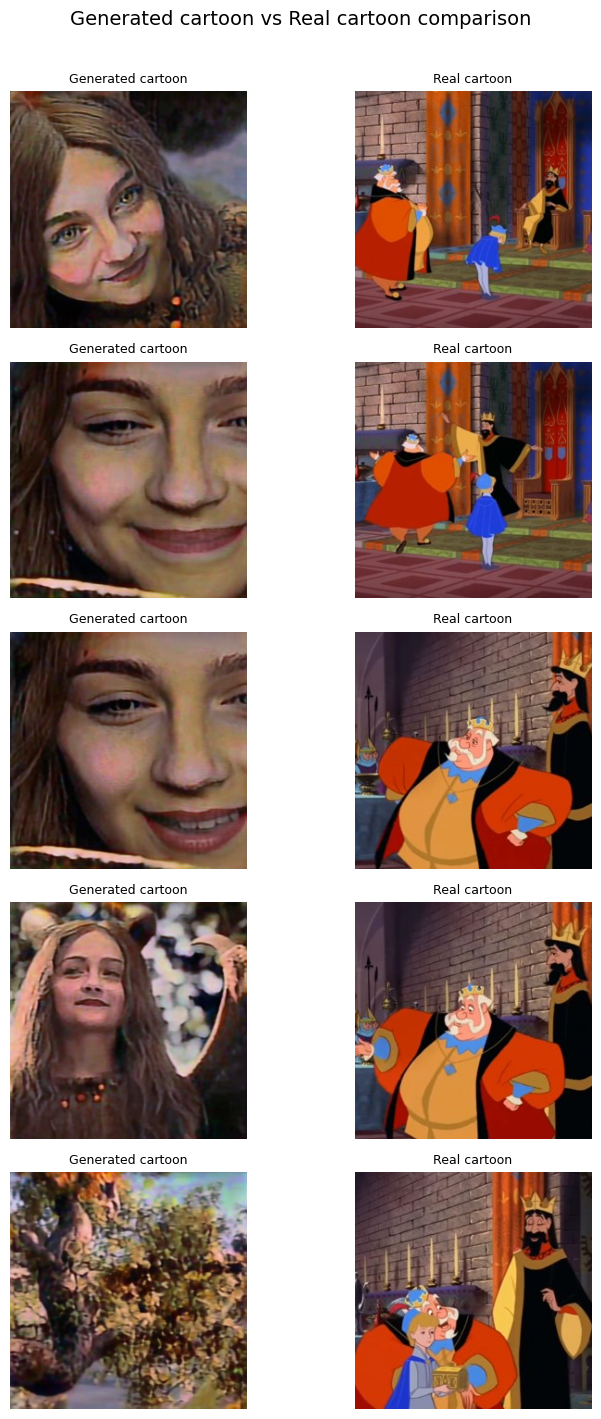

In [41]:
cartoon_files = list_image_files(cartoon_folder)
num_compare = min(5, len(results), len(cartoon_files))

real_cartoons = []
for i in range(num_compare):
    img = cv2.imread(os.path.join(cartoon_folder, cartoon_files[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (CROP_SIZE, CROP_SIZE))
    real_cartoons.append(img)

# Visualize: generated vs real cartoons
fig, axes = plt.subplots(num_compare, 2, figsize=(8, max(2.5, 2.8 * num_compare)))
axes = np.atleast_2d(axes)

for i in range(num_compare):
    axes[i, 0].imshow(results[i])
    axes[i, 0].set_title("Generated cartoon", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(real_cartoons[i])
    axes[i, 1].set_title("Real cartoon", fontsize=9)
    axes[i, 1].axis("off")

plt.suptitle("Generated cartoon vs Real cartoon comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [52]:
def calculate_fid(real_path, generated_images, device='cuda', img_size=256):
    from torchvision import transforms
    from torch.utils.data import DataLoader, Dataset
    from PIL import Image
    import os
    import numpy as np
    from pytorch_fid.inception import InceptionV3
    from pytorch_fid import fid_score


    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    class ImageFolder(Dataset):
        def __init__(self, folder):
            exts = {'.png', '.jpg', '.jpeg'}
            self.paths = [os.path.join(folder, f) for f in os.listdir(folder)
                         if os.path.splitext(f)[1].lower() in exts]
        def __len__(self): return len(self.paths)
        def __getitem__(self, i):
            return transform(Image.open(self.paths[i]).convert('RGB'))

    dims = 2048
    block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[dims]
    model = InceptionV3([block_idx]).to(device)
    model.eval()

    def get_stats_from_folder(folder):
        loader = DataLoader(ImageFolder(folder), batch_size=8,
                           num_workers=0, shuffle=False)
        acts = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                pred = model(batch)[0].squeeze(-1).squeeze(-1)
                acts.append(pred.cpu().numpy())
        acts = np.concatenate(acts, axis=0)
        mu = np.mean(acts, axis=0)
        sigma = np.cov(acts, rowvar=False)
        return mu, sigma

    def get_stats_from_arrays(images):
        acts = []
        with torch.no_grad():
            for img in images:
                img_pil = Image.fromarray(img)
                img_tensor = transform(img_pil).unsqueeze(0).to(device)
                pred = model(img_tensor)[0].squeeze(-1).squeeze(-1)
                acts.append(pred.cpu().numpy())
        acts = np.concatenate(acts, axis=0)
        mu = np.mean(acts, axis=0)
        sigma = np.cov(acts, rowvar=False)
        return mu, sigma

    print("Computing stats for real images...")
    m1, s1 = get_stats_from_folder(real_path)
    print("Computing stats for generated images...")
    m2, s2 = get_stats_from_arrays(generated_images)

    fid = fid_score.calculate_frechet_distance(m1, s1, m2, s2)
    print(f"\nFID: {fid:.4f}")
    return fid


fid = calculate_fid(
    real_path=cartoon_folder,
    generated_images=results,
    device=device
)

Computing stats for real images...
Computing stats for generated images...

FID: 321.8950
